## Scipy.integrate.odeint

#### Using odeint to solve a system of first order ordinary differential equations

---


Our term project modeled a system of N particles on a ring. The equation governing the motion of each particle is a system of coupled differential equations:

$$m\frac{d^2}{dt^2}\begin{bmatrix}{x_1}\cr{x_2}\cr{x_3}\cr{x_4}\end{bmatrix}=\begin{bmatrix}-2k&k&0&k\cr k&-2k&k&0\cr0&k&-2k&k\cr k&0&k&-2k\end{bmatrix}\begin{bmatrix}{x_1}\cr{x_2}\cr{x_3}\cr{x_4}\end{bmatrix}$$

We have solved this analytically many times, but finding a numerical solution introduces a new challenge. As a reminder of where this was used in the code, the following cell includes the numerical solution with the visualizations omitted.

In [2]:
import numpy as np
from scipy.integrate import odeint

# define function to separate the 2nd order ODE into a system of 1st order ODEs
def der(init, t, m, K):
    x = init[:N]
    v = init[N:]
    dxdt = v                   # velocity
    dvdt = np.dot(K,x) / m     # acceleration
    return np.concatenate([dxdt, dvdt])

m = 1
N = 4

# define K matrix
ks = np.arange(1,N+1,1)
# ks = np.ones(N)
K = np.diag(-ks - np.roll(ks, 1)) + np.diag(ks[:-1], k = 1) + np.diag(ks[:-1], k=-1)
K[[0,-1],[-1,0]] = ks[-1]

# define initial displacements (in radians)
x0 = np.zeros(N)
dx1 = .5
x0[0] = dx1

# crate initial position and velocity arrays
v0 = np.zeros_like(x0)
init = np.concatenate([x0, v0])

t = np.linspace(0, 50, 500)

# use scipy module to solve system of ODEs
solution = odeint(der, init, t, args=(m, K))

# separate the position from the velocity in the solution
x_t = solution[:, :N]

An initial struggle of this project was figuring out how to solve a second order ODE. Even odeint, which is what we eventually used, can only solve first order ODEs. However, the very useful thing about odeint is that it can also solve **systems** of ODEs. So, the first step to solving the second order ODE was decomposing it into a system of two first order ODEs.

To do this, we made the function "der", meaning derivative. This defines two derivatives of position representing the velocity and the acceleration. These two depend on each other, as the acceleration is the time derivative of velocity. We then concentrate, or combine, these two arrays into one variable, which is what the function returns.

---

Now that we have a way to decompose the differential eqaution, we can utilize odeint to solve this system. Let's look at the line below to see how odeint was implemented in the code.

In [3]:
solution = odeint(der, init, t, args=(m, K))

The first input into odeint is the function to be solved, which is specifically an array of derivative functions evaluated at initial values. In our case, the input function is the function we defined to separate the second order ODE. Below is the array produced by the derivative function. The first 4 (or N) terms represent the velocities ($dx/dt$) and the second set of 4 (or N) terms represent the accelerations ($dv/dt$) of each of the N particles. 

In [4]:
print(der(init, t, m, K))

[ 0.   0.   0.   0.  -2.5  0.5  0.   2. ]


The second input into odeint is the intial condition on the function (first input). For our solution, "init" is the concentrated array of initial conditions for the positions and velocities of each particle on the ring. The "init" array is printed below.

In [5]:
print(init)

[0.5 0.  0.  0.  0.  0.  0.  0. ]


The third input is the independent variable used to solve the differential equation. In this case, it is an array of times.

The fourth and final input into odeint is "args". This defines extra parameters that are passed into the function, which is the first input. As a feature of odeint, it will plug in parameters to the function that it is given. This is why we can input just "der" as the first input, instead of actually running the function. The other inputs to odeint will be passed into "der", which is why we will input variables as "args". We pass m and K, the masses and spring constant array, as "args", which are input into the derivative function.

As a general form, the inputs to odeint are as follows:


`odeint(function, intital condition(s), independent variable, extra argument(s))`.

---
Now, let's look at what odeint returns for us by visualizing the results.

In [6]:
print(solution)

[[ 5.00000000e-01  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 4.87537766e-01  2.49329525e-03  2.92400861e-05 ...  4.94334597e-02
   1.16404922e-03  1.96399608e-01]
 [ 4.51192345e-01  9.77550227e-03  4.60165011e-04 ...  9.49600536e-02
   9.08362647e-03  3.69336251e-01]
 ...
 [-9.85908145e-02  8.13110643e-02  2.57103246e-01 ...  2.36328221e-01
   3.22031106e-01 -6.82609489e-01]
 [-7.86098691e-02  1.05863957e-01  2.87111550e-01 ...  2.53856290e-01
   2.71504028e-01 -7.93679015e-01]
 [-4.62403250e-02  1.32198930e-01  3.10435912e-01 ...  2.71793045e-01
   1.88861736e-01 -8.30674398e-01]]


This looks gross, but it's exactly what we intended. Odeint returns a numerical solution for the displacement and velocity of each of the N particles over the time t that we input. We can very easily visualize this by decomposing the solution array into a displacement and velocity array, then creating a displacement and velocity plot for each mass.

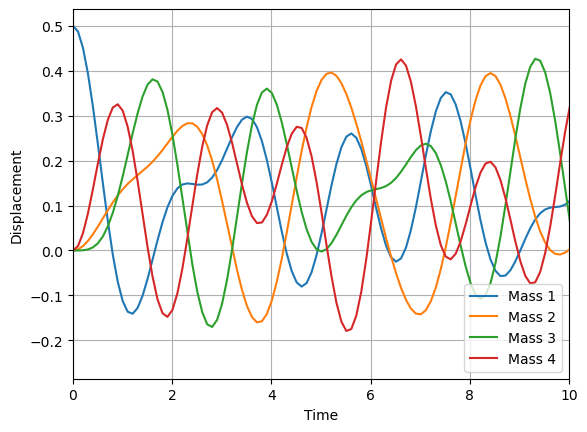

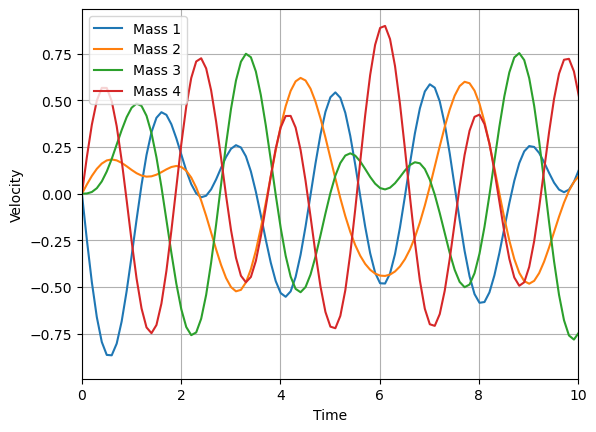

In [7]:
import matplotlib.pyplot as plt

x_t = solution[:, :N]
v_t = solution[:, N:]

# plot the displacement of each mass over time
for i in range(N):
    plt.plot(t, x_t[:,i], label = f"Mass {i+1}")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.xlim(0,10)
plt.legend()
plt.grid()
plt.show()

# plot the velocity of each mass over time
for i in range(N):
    plt.plot(t, v_t[:,i], label = f"Mass {i+1}")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.xlim(0,10)
plt.legend()
plt.grid()
plt.show()

These graphs look very hard to understand, but that is because the spring constants are all different and the system is not in an eigenstate. We can alter some of our initial conditions and the spring constants to put the system in a stable state.

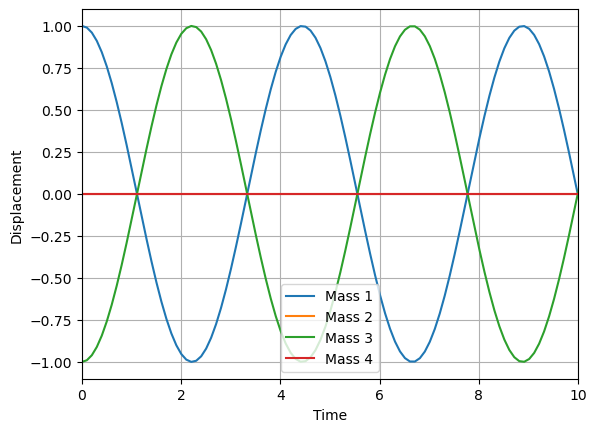

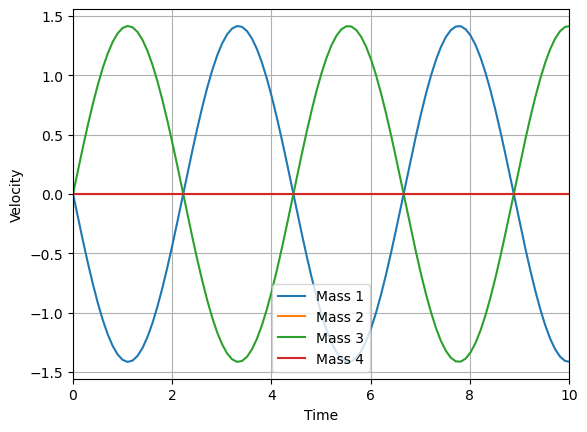

In [8]:
import numpy as np
from scipy.integrate import odeint

# define function to separate the 2nd order ODE into a system of 1st order ODEs
def der(init, t, m, K):
    x = init[:N]
    v = init[N:]
    dxdt = v                   # velocity
    dvdt = np.dot(K,x) / m     # acceleration
    return np.concatenate([dxdt, dvdt])

m = 1
N = 4

# define K matrix
ks = np.ones(N)
K = np.diag(-ks - np.roll(ks, 1)) + np.diag(ks[:-1], k = 1) + np.diag(ks[:-1], k=-1)
K[[0,-1],[-1,0]] = ks[-1]

# define initial displacements (in radians)
x0 = np.array([1,0,-1,0])

# crate initial position and velocity arrays
v0 = np.zeros_like(x0)
init = np.concatenate([x0, v0])

t = np.linspace(0, 50, 500)

# use scipy module to solve system of ODEs
solution = odeint(der, init, t, args=(m, K))

import matplotlib.pyplot as plt

x_t = solution[:, :N]
v_t = solution[:, N:]

# plot the displacement of each mass over time
for i in range(N):
    plt.plot(t, x_t[:,i], label = f"Mass {i+1}")
plt.xlabel("Time")
plt.ylabel("Displacement")
plt.xlim(0,10)
plt.legend()
plt.grid()
plt.show()

# plot the velocity of each mass over time
for i in range(N):
    plt.plot(t, v_t[:,i], label = f"Mass {i+1}")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.xlim(0,10)
plt.legend()
plt.grid()
plt.show()

These graphs of the simpler system clearly show that the displacement and velocity are out of phase by $\pi/2$, which is the relationship we expect these variables to have. Odeint makes solving this system very easy, and works for systems of all levels of complexity.

---
As a summary, scipy.integrate.odeint is very useful to solve differential equations. Analytically, we can solve the system of 4 particles on a ring, simply by using solutions methods for second order differential equations. This method must be changed to solve this problem numerically. Instead of solving one second order ODE, we have to challenge our method to solve it as multiple first order ODEs. This function makes seemingly difficult calculations very simple, and is a very useful tool to understand.